# Análise Exploratória de Dados (EDA)

O objetivo desta etapa é explorar o conjunto de dados após o processo de limpeza, buscando identificar padrões, relações e características associadas ao cancelamento dos clientes (Churn).

> A descrição do problema e o dicionário de variáveis estão no `README.md`.
> Aqui eu explico só o que é necessário para ler cada gráfico.



## Importando as bibliotecas

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency

pd.set_option("display.max_columns", 60)

## Carregando a base limpa

In [5]:
df_analise = pd.read_csv('../data/processed/Telco-Customer-Churn-clean.csv')
display(df_analise)

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,1,1,24,1,1,DSL,1,0,1,1,1,1,One year,1,Mailed check,84.80,1990.50,0
7039,2234-XADUH,Female,0,1,1,72,1,1,Fiber optic,0,1,1,0,1,1,One year,1,Credit card (automatic),103.20,7362.90,0
7040,4801-JZAZL,Female,0,1,1,11,0,0,DSL,1,0,0,0,0,0,Month-to-month,1,Electronic check,29.60,346.45,0
7041,8361-LTMKD,Male,1,1,0,4,1,1,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Mailed check,74.40,306.60,1


## Observando a variável Target

,clientes,%
churn,,
0,5174,73.5
1,1869,26.5


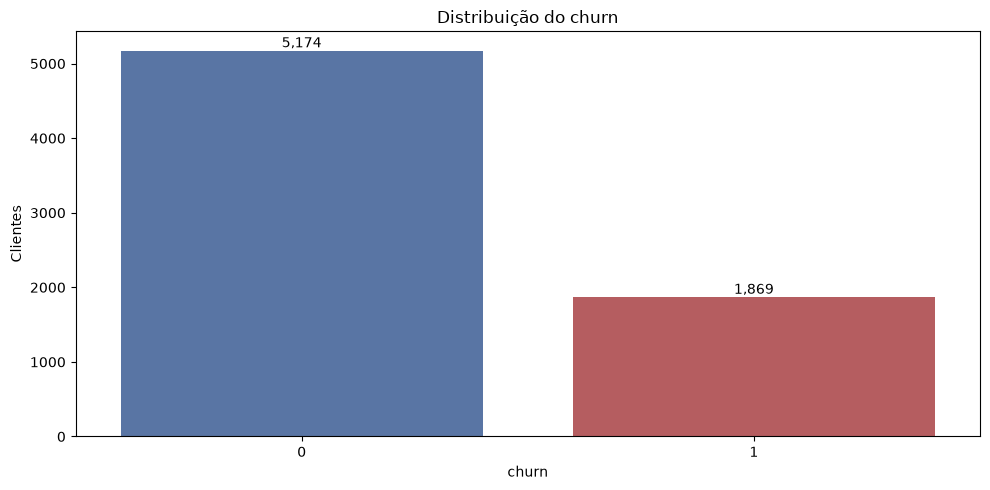

Taxa de churn global: 26.5%  (baseline: prever 'ninguém sai' acerta 73.5%)


In [8]:
COR_CHURN = {0: "#4C72B0", 1: "#C44E52"}   
contagem = df_analise['churn'].value_counts()
pct = df_analise['churn'].value_counts(normalize=True) * 100 # porcentagem de churn
display(pd.DataFrame({"clientes": contagem, "%": pct.round(1)}))

taxa_global = df_analise["churn"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df_analise, x='churn', hue='churn', order=[0, 1],
              palette=COR_CHURN, legend=False, ax=ax)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
ax.set_title("Distribuição do churn")
ax.set_ylabel("Clientes")
plt.tight_layout()
plt.show()

print(f"Taxa de churn global: {taxa_global:.1%}  (baseline: prever 'ninguém sai' acerta {1 - taxa_global:.1%})")

## Análise univariada

In [9]:
# Listas de colunas reutilizadas em todo o notebook
num_cols = ["tenure", "monthly_charges", "total_charges"]
cat_cols = [c for c in df_analise.columns
            if c not in num_cols + ["customer_id", 'churn']]

print(f"{len(num_cols)} numéricas | {len(cat_cols)} categóricas")
print("Categóricas:", cat_cols)

3 numéricas | 16 categóricas
Categóricas: ['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method']


### Numéricas

,count,mean,std,min,25%,50%,75%,max,assimetria
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00,0.239540
monthly_charges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75,-0.220524
total_charges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80,0.963235


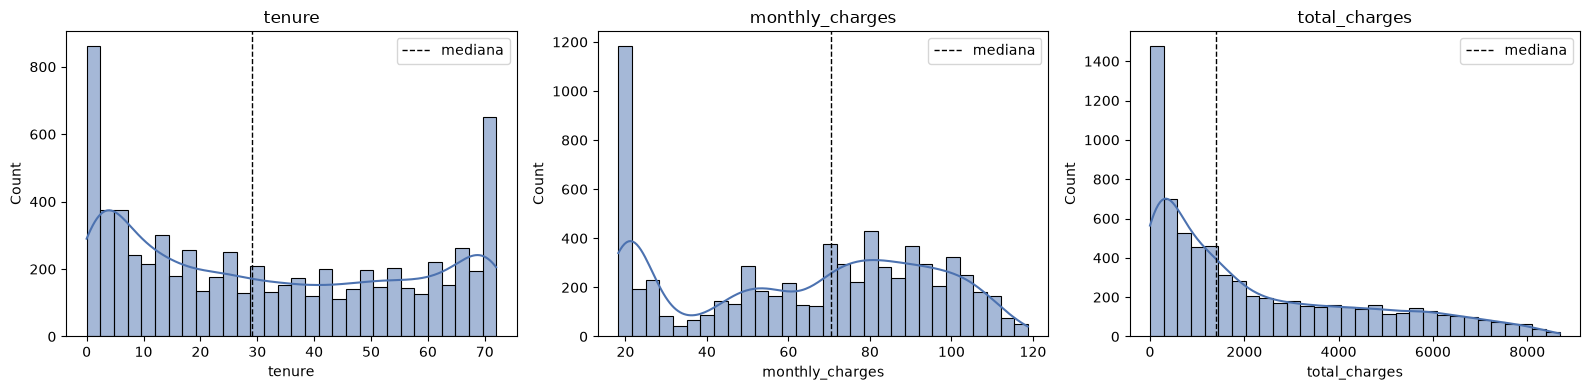

In [10]:
display(df_analise[num_cols].describe().T.assign(assimetria=df_analise[num_cols].skew()))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df_analise[col], bins=30, kde=True, ax=ax, color="#4C72B0")
    ax.axvline(df_analise[col].median(), color="k", ls="--", lw=1, label="mediana")
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

- `tenure`: distribuição bimodal (muitos clientes novos e muitos com ~70 meses).
- `MonthlyCharges`: pico em ~20  e massa entre 70 e 100 .
- `TotalCharges`: assimetria positiva, consequência de acumular tenure × mensalidade.

In [53]:
(df_analise["total_charges"] / (df_analise["tenure"] * df_analise["monthly_charges"])).describe()

count    7032.000000
mean        1.000275
std         0.051159
min         0.689356
25%         0.979546
50%         1.000000
75%         1.019562
max         1.573454
dtype: float64

### Categóricas

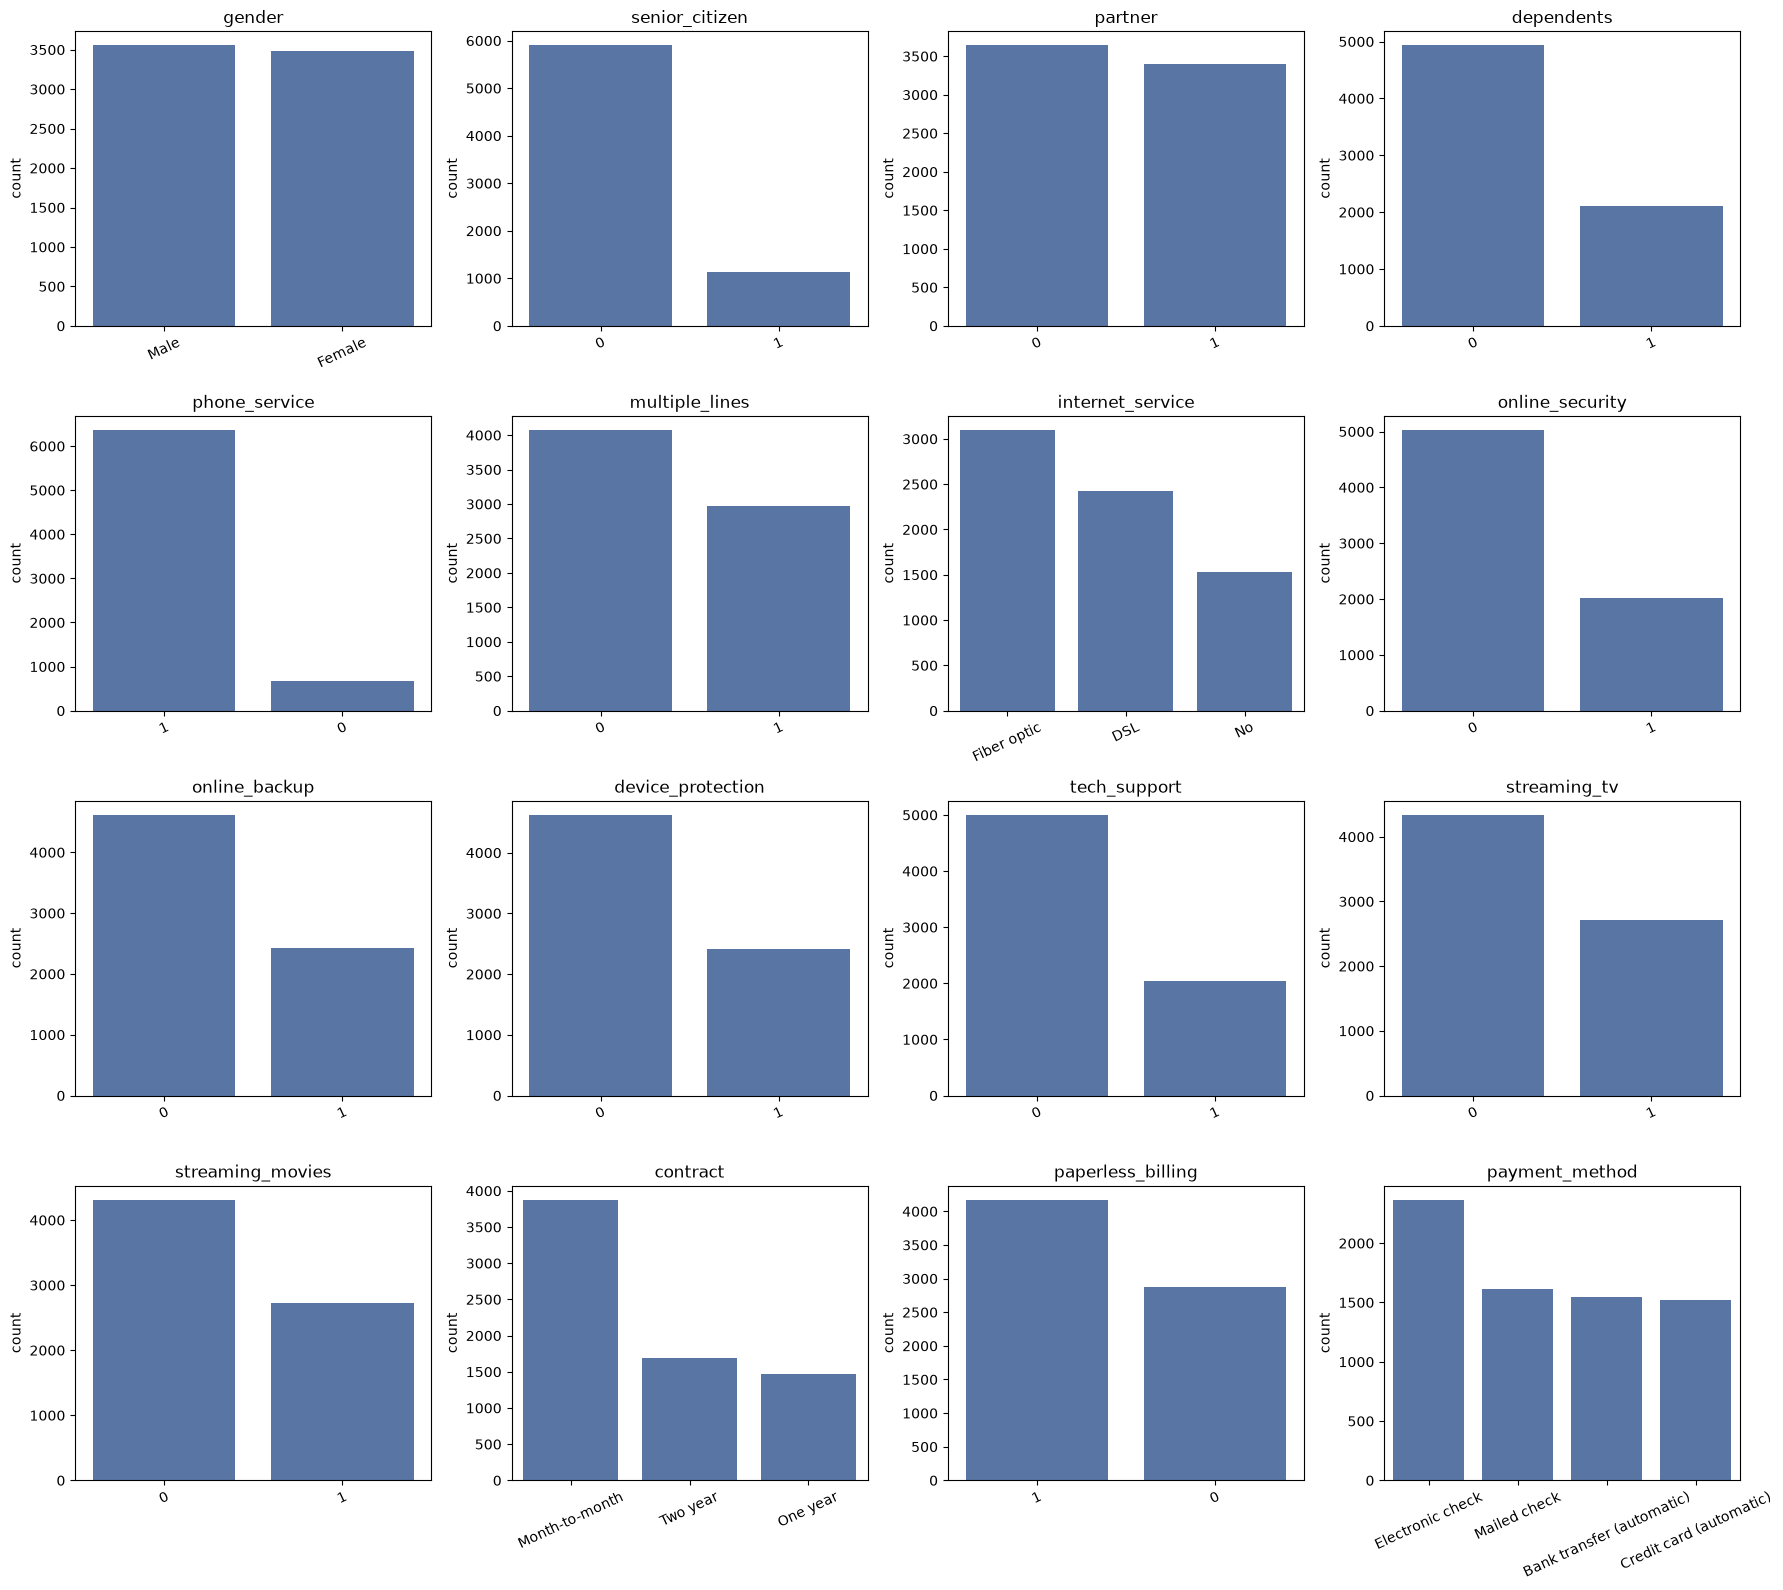

In [11]:
n_cols = 4
n_rows = int(np.ceil(len(cat_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
for ax, col in zip(axes.ravel(), cat_cols):
    ordem = df_analise[col].value_counts().index
    sns.countplot(data=df_analise, x=col, order=ordem, ax=ax, color="#4C72B0")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
for ax in axes.ravel()[len(cat_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

Nenhuma categoria é extremamente rara, então não há necessidade de agrupar níveis. Chamam atenção: contrato mensal é o mais comum (~55%) e fibra óptica é o serviço de internet mais contratado.

## Análise Bivariada

### Variáveis numéricas x Churn

churn                        0       1
tenure          mean      37.6    18.0
                median    38.0    10.0
monthly_charges mean      61.3    74.4
                median    64.4    79.6
total_charges   mean    2549.9  1531.8
                median  1679.5   703.6

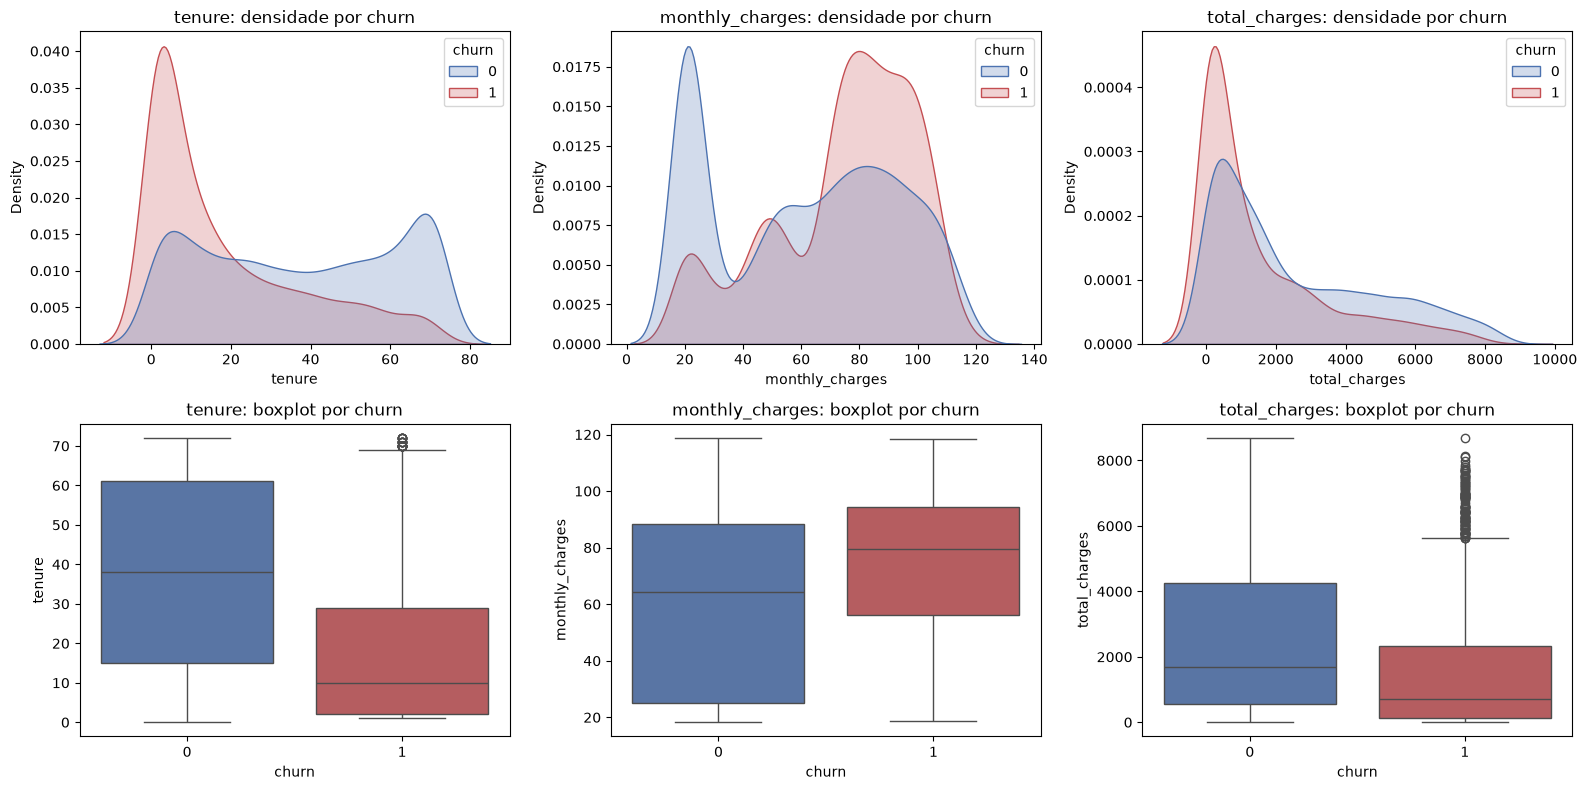

In [12]:
display(df_analise.groupby('churn')[num_cols].agg(["mean", "median"]).round(1).T)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, col in enumerate(num_cols):
    sns.kdeplot(data=df_analise, x=col, hue='churn', common_norm=False, fill=True,
                palette=COR_CHURN, ax=axes[0, i])
    axes[0, i].set_title(f"{col}: densidade por churn")
    sns.boxplot(data=df_analise, x='churn', y=col, hue='churn', order=[0, 1],
                palette=COR_CHURN, legend=False, ax=axes[1, i])
    axes[1, i].set_title(f"{col}: boxplot por churn")
plt.tight_layout()
plt.show()

- `tenure`: quem sai tem mediana de ~10 meses contra ~38 de quem fica. É a variável numérica mais discriminante.
- `MonthlyCharges`: quem sai paga mais em média (~74 vs ~61).
- `TotalCharges`: menor entre quem sai, mas isso é reflexo do tenure baixo, não um efeito próprio.

Variáveis numéricas contínuas escondem padrões não lineares. Discretizamos em faixas para ver a taxa de churn em cada uma.

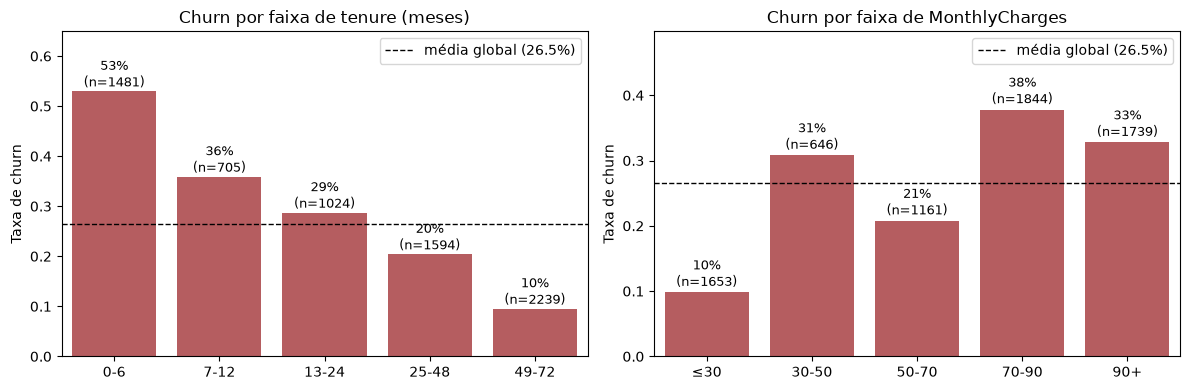

In [13]:
def taxa_por_faixa(serie, bins, labels=None):
    faixas = pd.cut(serie, bins=bins, labels=labels, include_lowest=True)
    return df_analise.groupby(faixas, observed=True)["churn"].agg(taxa="mean", n="count")

tenure_faixas = taxa_por_faixa(df_analise["tenure"], [0, 6, 12, 24, 48, 72],
                               ["0-6", "7-12", "13-24", "25-48", "49-72"])
mensal_faixas = taxa_por_faixa(df_analise["monthly_charges"], [0, 30, 50, 70, 90, 120],
                               ["≤30", "30-50", "50-70", "70-90", "90+"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, tab, titulo in zip(axes, [tenure_faixas, mensal_faixas],
                           ["Churn por faixa de tenure (meses)", "Churn por faixa de MonthlyCharges"]):
    sns.barplot(x=tab.index.astype(str), y=tab["taxa"], color="#C44E52", ax=ax)
    ax.axhline(taxa_global, color="k", ls="--", lw=1, label=f"média global ({taxa_global:.1%})")
    for i, (t, n) in enumerate(zip(tab["taxa"], tab["n"])):
        ax.text(i, t + 0.01, f"{t:.0%}\n(n={n})", ha="center", fontsize=9)
    ax.set_title(titulo)
    ax.set_ylabel("Taxa de churn")
    ax.set_xlabel("")
    ax.set_ylim(0, tab["taxa"].max() + 0.12)
    ax.legend()
plt.tight_layout()
plt.show()

O risco é altíssimo nos primeiros 6 meses (~53%) e cai de forma monotônica até ~10% depois de 4 anos. Para `MonthlyCharges` a relação não é linear: a faixa ≤30 é muito segura (grande parte são clientes sem internet), e o churn dispara acima de 70.

### Variáveis categóricas x Churn

Para cada categoria calculamos a taxa de churn . A linha tracejada é a média global: barras acima dela são grupos de risco.

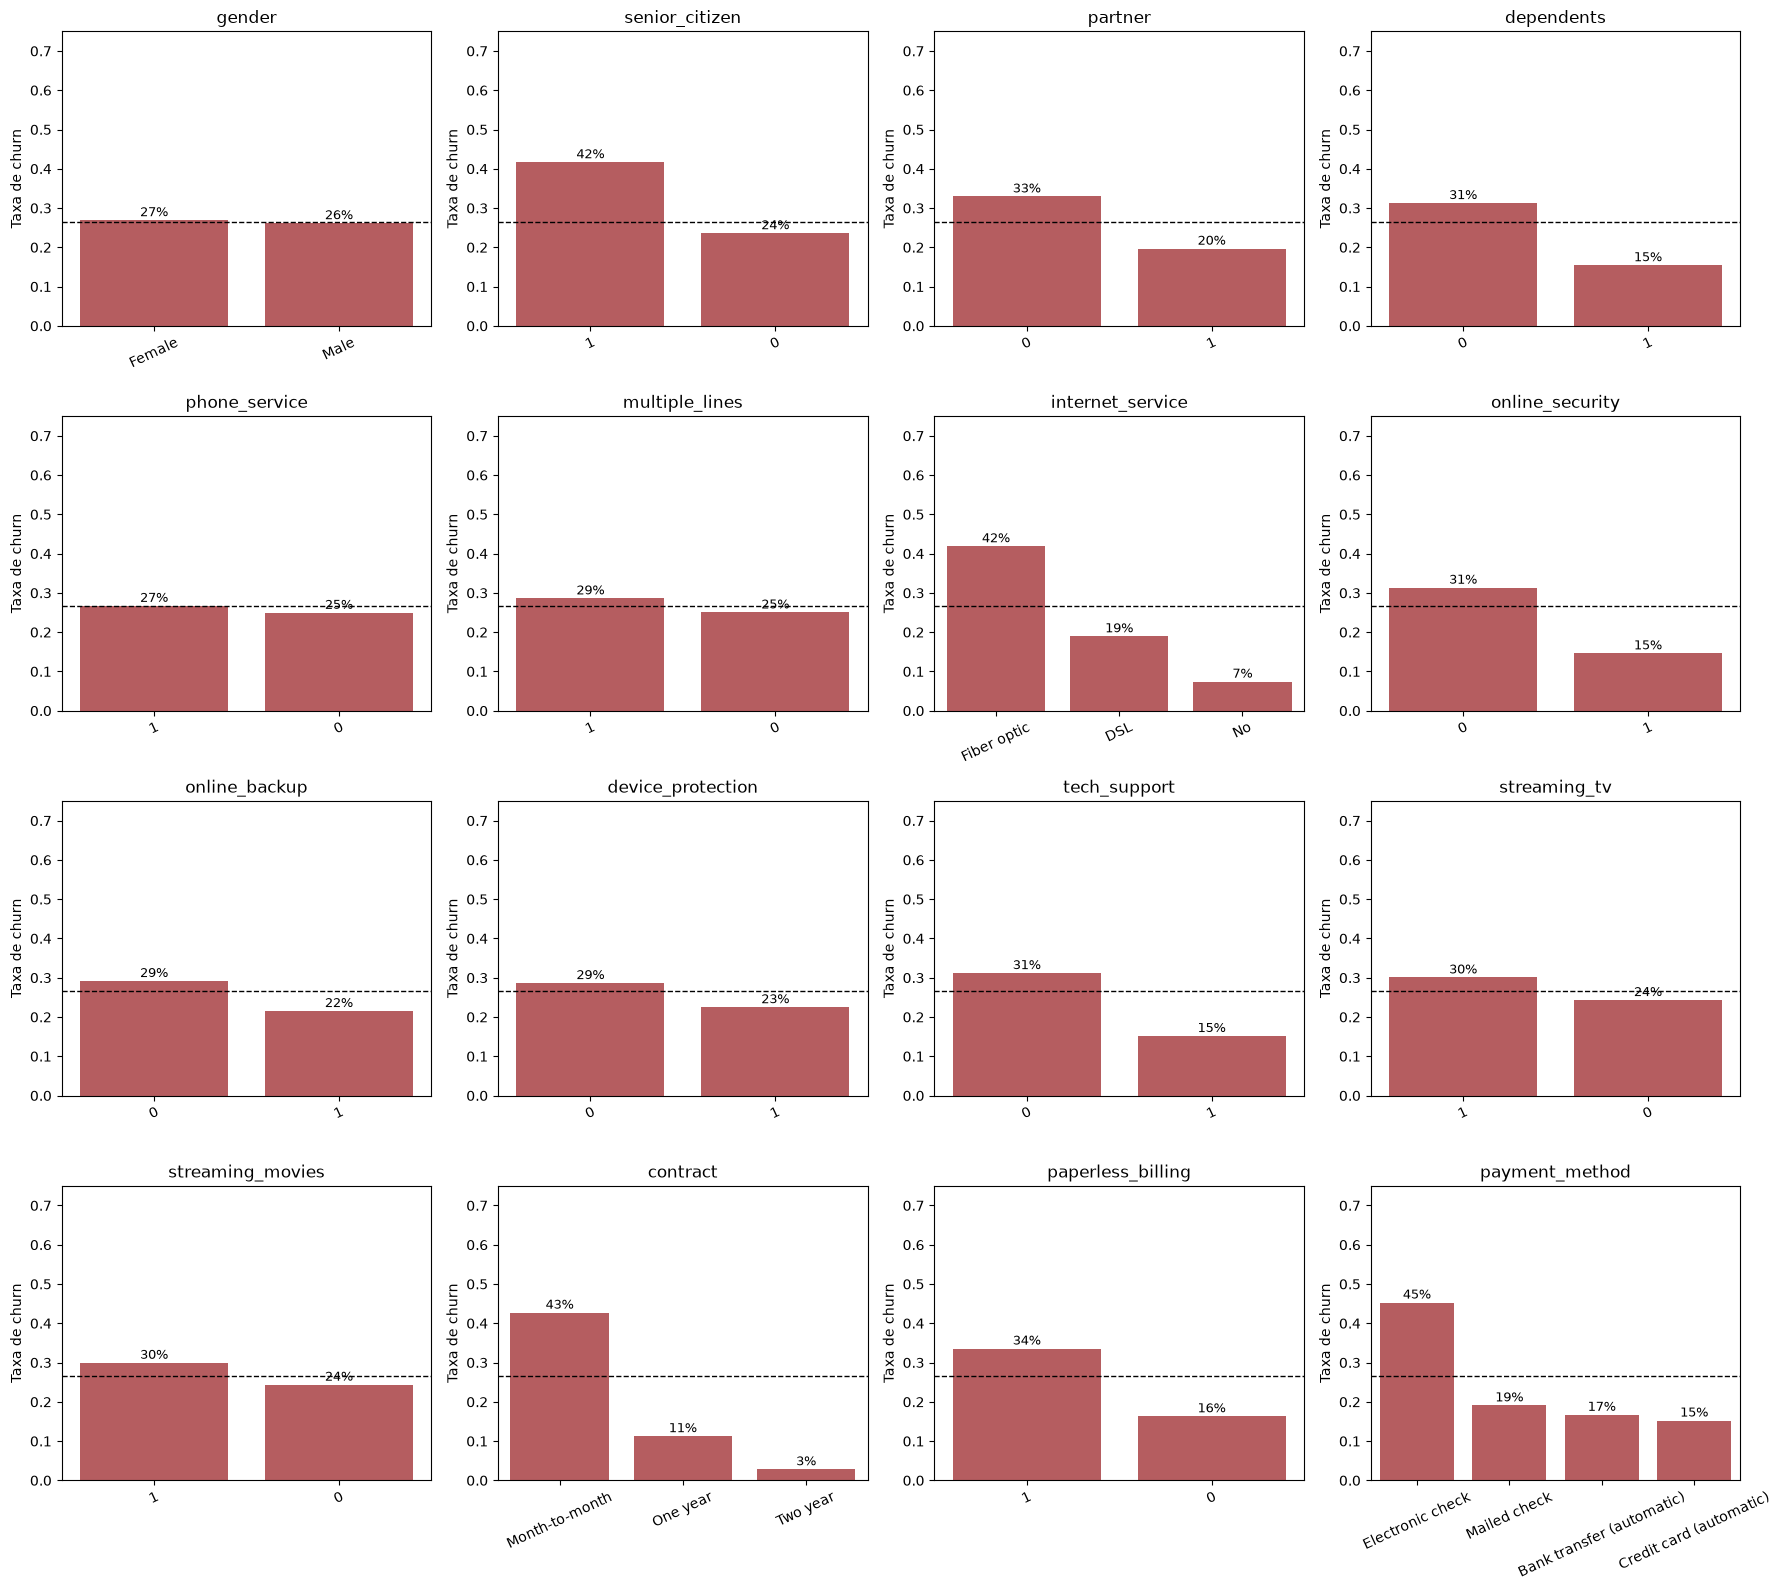

In [15]:




def taxa_churn(col):
    return (df_analise.groupby(col)["churn"].agg(taxa="mean", n="count")
              .reset_index().sort_values("taxa", ascending=False))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
for ax, col in zip(axes.ravel(), cat_cols):
    tab = taxa_churn(col)
    sns.barplot(data=tab, x=col, y="taxa", color="#C44E52", ax=ax,order = tab[col])
    ax.axhline(taxa_global, color="k", ls="--", lw=1)
    for i, t in enumerate(tab["taxa"]):
        ax.text(i, t + 0.01, f"{t:.0%}", ha="center", fontsize=9)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Taxa de churn")
    ax.set_ylim(0, 0.75)
    ax.tick_params(axis="x", rotation=25)
for ax in axes.ravel()[len(cat_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

## Ranking de importância (associação com o churn)
Os gráficos mostram como cada variável se relaciona com o churn; agora medimos quanto.


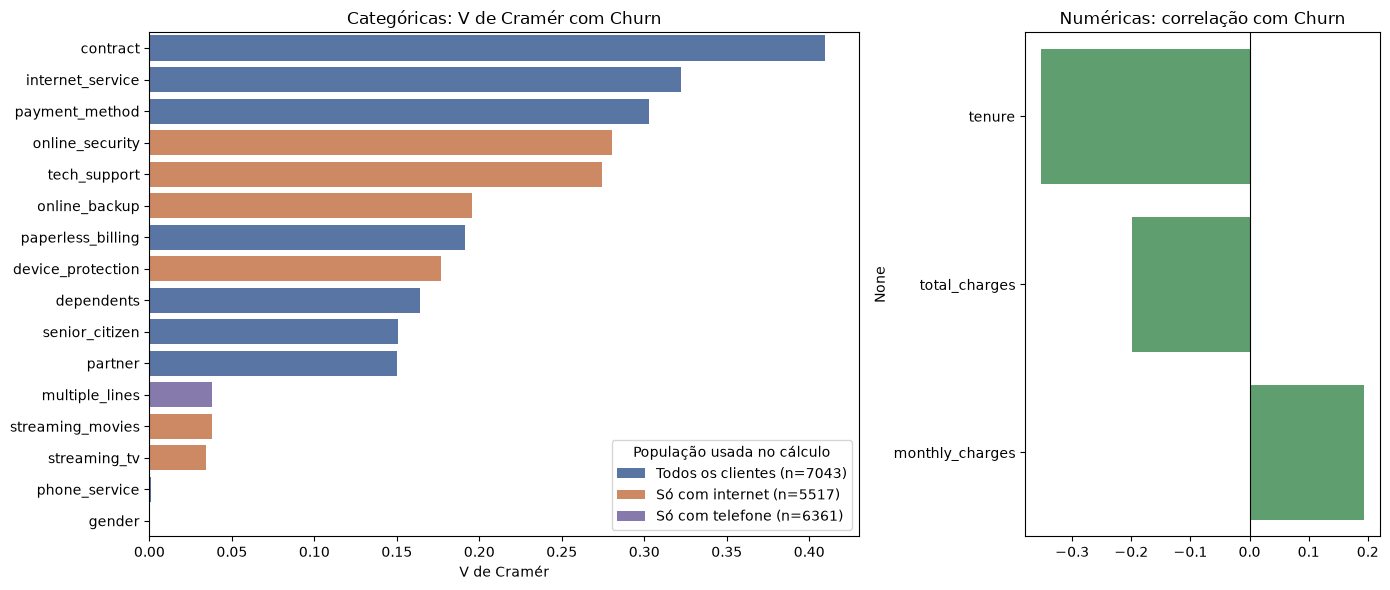

,v,populacao
variavel,,
contract,0.410,Todos os clientes (n=7043)
internet_service,0.322,Todos os clientes (n=7043)
payment_method,0.303,Todos os clientes (n=7043)
online_security,0.281,Só com internet (n=5517)
tech_support,0.274,Só com internet (n=5517)
online_backup,0.196,Só com internet (n=5517)
paperless_billing,0.191,Todos os clientes (n=7043)
device_protection,0.177,Só com internet (n=5517)
dependents,0.164,Todos os clientes (n=7043)


In [42]:
def cramers_v(x, y):
    tab = pd.crosstab(x, y)
    chi2 = chi2_contingency(tab, correction=False)[0]
    n = tab.values.sum()
    r, k = tab.shape
    phi2 = max(0, chi2 / n - ((k - 1) * (r - 1)) / (n - 1))
    rc = r - ((r - 1) ** 2) / (n - 1)
    kc = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2 / min(kc - 1, rc - 1))

com_internet = df_analise[df_analise["internet_service"] != "No"]
com_telefone = df_analise[df_analise["phone_service"] == 1]

COLS_INTERNET = ["online_security", "tech_support", "online_backup",
                 "device_protection", "streaming_tv", "streaming_movies"]
COLS_TELEFONE = ["multiple_lines"]

POP_TODOS    = f"Todos os clientes (n={len(df_analise)})"
POP_INTERNET = f"Só com internet (n={len(com_internet)})"
POP_TELEFONE = f"Só com telefone (n={len(com_telefone)})"

linhas = []
for c in cat_cols:
    if c in COLS_INTERNET:
        base, pop = com_internet, POP_INTERNET
    elif c in COLS_TELEFONE:
        base, pop = com_telefone, POP_TELEFONE
    else:
        base, pop = df_analise, POP_TODOS
    linhas.append({"variavel": c,
                   "v": cramers_v(base[c], base["churn"]),
                   "populacao": pop})

assoc_cat = pd.DataFrame(linhas).sort_values("v", ascending=False)

assoc_num = (df_analise[num_cols].corrwith(df_analise["churn"])
             .sort_values(key=abs, ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [2, 1]})

sns.barplot(data=assoc_cat, x="v", y="variavel", hue="populacao", dodge=False,
            palette={POP_TODOS: "#4C72B0", POP_INTERNET: "#DD8452", POP_TELEFONE: "#8172B3"},
            ax=axes[0])
axes[0].set_title("Categóricas: V de Cramér com Churn")
axes[0].set_xlabel("V de Cramér")
axes[0].set_ylabel("")
axes[0].legend(title="População usada no cálculo", loc="lower right")

sns.barplot(x=assoc_num.values, y=assoc_num.index, color="#55A868", ax=axes[1])
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_title("Numéricas: correlação com Churn")

plt.tight_layout()
plt.show()

display(assoc_cat.set_index("variavel").round(3))

## Associação das variáveis categóricas com o churn (V de Cramér)

O V de Cramér mede a associação entre duas variáveis categóricas, em uma escala de 0 (nenhuma associação) a 1 (associação perfeita). Ele não tem sinal, então não mostra a direção do efeito. Usei a versão com correção de viés (Bergsma), que evita superestimar a associação em tabelas com muitas categorias.

As colunas `online_security`, `tech_support`, `online_backup`, `device_protection`, `streaming_tv` e `streaming_movies` só fazem sentido para clientes que têm internet. Na base original, quem não tem internet aparece com o nível `No internet service`, que é idêntico a `internet_service == "No"` e tem o churn mais baixo da base. Isso causa dois problemas:

- **Manter o nível:** o V fica inflado, porque a coluna passa a refletir "ter ou não ter internet" além de "ter ou não ter o serviço".
- **Fundir com `No`:** o grupo `No` mistura quem não tem internet com quem tem e não contratou. O V fica diluído.

**Abordagem utilizada:** calculei o V desses serviços apenas entre clientes com internet (`internet_service != "No"`). O mesmo vale para `multiple_lines`, calculado apenas entre quem tem telefone (`phone_service == 1`). Assim o V mede só o efeito do serviço em si.

| Variável | Bruta | `No` fundido | Só com internet |
|---|---|---|---|
| online_security | 0,347 | 0,171 | 0,281 |
| tech_support | 0,343 | 0,164 | 0,274 |
| online_backup | 0,292 | 0,081 | 0,196 |
| device_protection | 0,281 | 0,065 | 0,177 |
| streaming_tv | 0,230 | 0,062 | 0,035 |
| streaming_movies | 0,230 | 0,060 | 0,038 |

 `online_security` e `tech_support` têm a maior associação com o churn entre os serviços. `online_backup` e `device_protection` ficam num patamar intermediário. `streaming_tv`, `streaming_movies` e `multiple_lines` têm associação praticamente nula.

**Limitações:**
- Os V dos serviços foram calculados em um subconjunto da base, então não são diretamente comparáveis aos de `contract` ou `payment_method`, que usam todos os clientes.
- O V mede associação, não causalidade nem importância no modelo.
- Para saber a direção do efeito, é preciso olhar a taxa de churn por categoria, no caso, o gráfico feito na sessão categorica x churn.

## Análise Multivariada

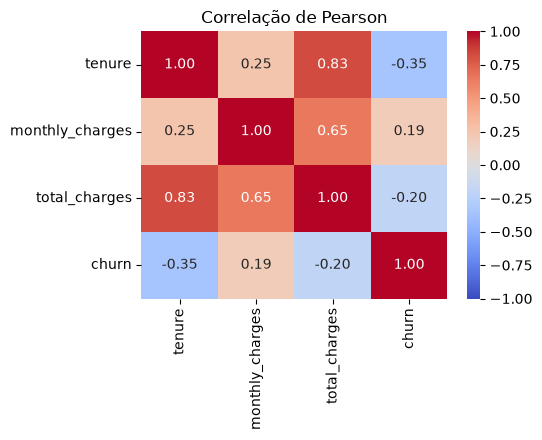

In [43]:
corr = df_analise[num_cols + ["churn"]].corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlação de Pearson")
plt.tight_layout()
plt.show()

`TotalCharges` tem correlação alta com `tenure` (~0,83) e com `MonthlyCharges` (~0,65): é em grande parte a multiplicação das duas.

## Verificando a concentração do Risco

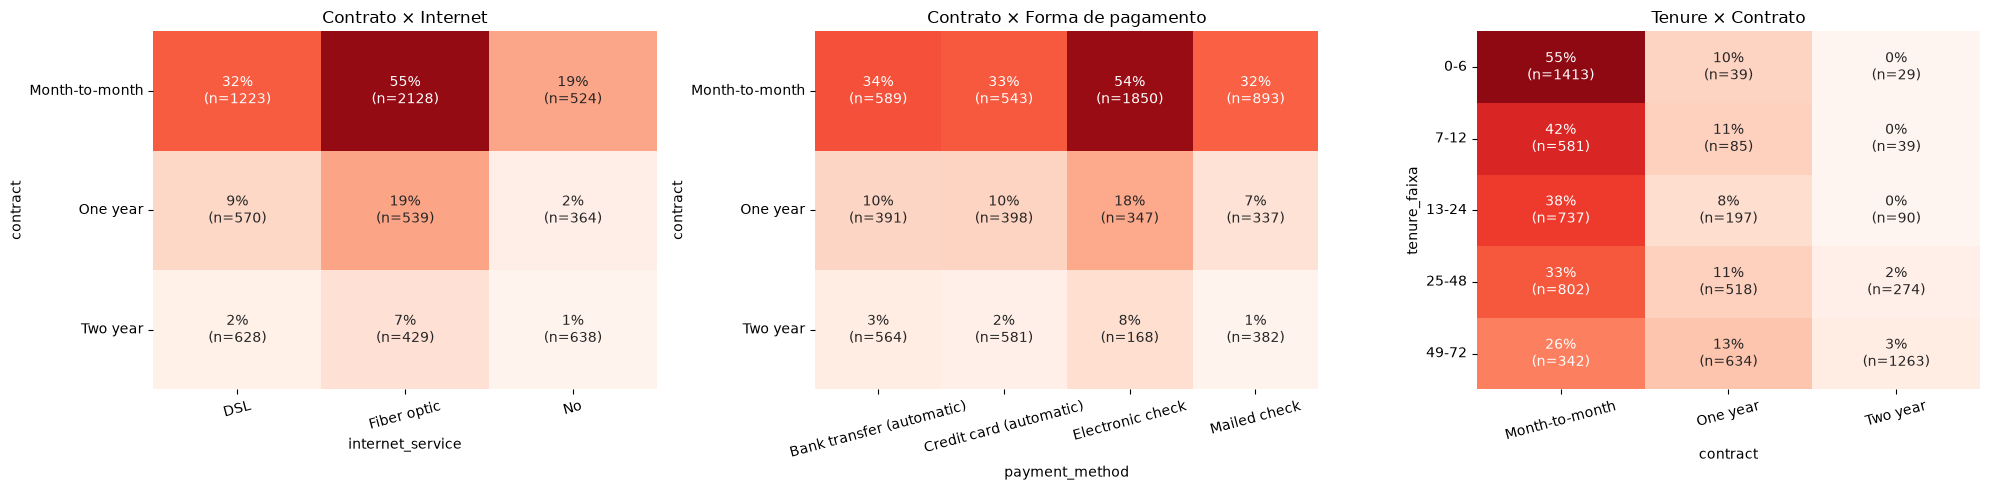

In [44]:
ORDEM_CONTRATO = ["Month-to-month", "One year", "Two year"]

def heatmap_churn(linhas, colunas, ax, titulo):
    tab = df_analise.pivot_table(index=linhas, columns=colunas, values="churn", aggfunc="mean")
    n = df_analise.pivot_table(index=linhas, columns=colunas, values="churn", aggfunc="count")
    if linhas == "Contract":                      # ordem lógica: do mais curto ao mais longo
        tab, n = tab.loc[ORDEM_CONTRATO], n.loc[ORDEM_CONTRATO]
    if colunas == "Contract":
        tab, n = tab[ORDEM_CONTRATO], n[ORDEM_CONTRATO]
    anot = tab.map(lambda v: f"{v:.0%}") + "\n(n=" + n.astype(int).astype(str) + ")"
    sns.heatmap(tab, annot=anot, fmt="", cmap="Reds", vmin=0, vmax=0.6, cbar=False, ax=ax)
    ax.set_title(titulo)
    ax.tick_params(axis="y", rotation=0)
    ax.tick_params(axis="x", rotation=15)

df_analise["tenure_faixa"] = pd.cut(df_analise["tenure"], [0, 6, 12, 24, 48, 72],
                            labels=["0-6", "7-12", "13-24", "25-48", "49-72"], include_lowest=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
heatmap_churn("contract", "internet_service", axes[0], "Contrato × Internet")
heatmap_churn("contract", "payment_method", axes[1], "Contrato × Forma de pagamento")
heatmap_churn("tenure_faixa", "contract", axes[2], "Tenure × Contrato")
plt.tight_layout()
plt.show()

- Contrato mensal + fibra óptica é o segmento mais crítico (~55% de churn em ~2.100 clientes).
- O efeito ruim do cheque eletrônico aparece sobretudo nos contratos mensais.
- Os contratos de 1 e 2 anos protegem em todos os cruzamentos, inclusive nos primeiros meses, mas há poucos clientes com contrato longo e tenure baixo, por isso as células têm `n` pequeno.

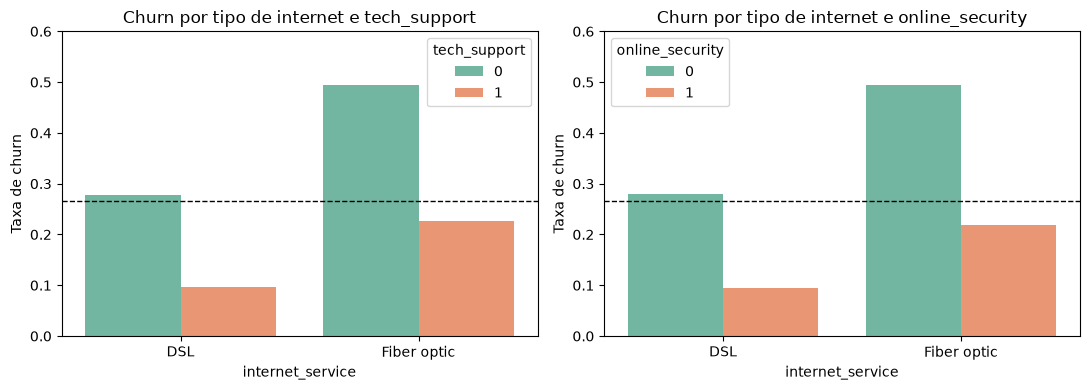

In [45]:
# Serviços de suporte/segurança dentro de cada tipo de internet
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ["tech_support", "online_security"]):
    sub = df_analise[df_analise["internet_service"] != "No"]
    tab = sub.groupby(["internet_service", col])["churn"].mean().reset_index()
    sns.barplot(data=tab, x="internet_service", y="churn", hue=col, ax=ax, palette="Set2")
    ax.axhline(taxa_global, color="k", ls="--", lw=1)
    ax.set_title(f"Churn por tipo de internet e {col}")
    ax.set_ylabel("Taxa de churn")
    ax.set_ylim(0, 0.6)
plt.tight_layout()
plt.show()

 Dentro de cada tipo de internet, quem tem suporte técnico/segurança online sai bem menos. Ou seja, o efeito não é só "fibra vs DSL". Continua sendo correlação, porém tempo de contrato pode ser o fator oculto.

## Conclusões da EDA

**Target**
- A taxa de churn é de aproximadamente 26,5%, o que indica desbalanceamento moderado.

**Principais associações com o churn**
- `contract` é a variável mais associada ao churn (V de Cramér ≈ 0,41). Contrato mensal tem churn de ~43%, contra 11% no de 1 ano e 3% no de 2 anos.
- O churn é maior entre clientes com menor tempo de permanência, especialmente nos primeiros meses.
- Clientes com fibra óptica têm churn de 42%, contra 19% com DSL e 7% sem internet. A combinação contrato mensal + fibra óptica tem taxa particularmente alta (55%).
- `payment_method` (V ≈ 0,30): electronic check tem uma das maiores taxas de churn (45%).
- Entre clientes com internet, a ausência de `online_security` e `tech_support` está associada a mais churn (V ≈ 0,28 e 0,27). `online_backup` e `device_protection` têm associação menor (V ≈ 0,20 e 0,18).

**Variáveis pouco associadas**
- `gender`, `phone_service`, `multiple_lines`, `streaming_tv` e `streaming_movies` têm pouca diferença entre categorias (V < 0,04).

**Observações**
- Os V dos serviços de internet foram calculados apenas entre clientes com internet, e o de `multiple_lines` apenas entre clientes com telefone, para não misturar o efeito de ter o serviço com o de ter a infraestrutura. Por isso não são diretamente comparáveis aos demais.
- A associação entre `online_security` e `tech_support` é moderada (V ≈ 0,27), sem indício de redundância forte.
- As variáveis se relacionam entre si (por exemplo, contrato e tempo de permanência), então os padrões isolados podem refletir efeitos combinados. A EDA é observacional e as associações não indicam causalidade.

**Modelagem**
- Usar divisão estratificada e métricas adequadas a classes desbalanceadas , além de definir o limiar de decisão.
- Comparar o ranking de associação com a importância no modelo (permutation importance e SHAP).